# Garbage Classification Inference

Use this notebook to load the trained model, choose an image path, and inspect the predicted garbage class with top-k probabilities.

In [23]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from IPython.display import display

candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src").exists() and (candidate / "outputs").exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root from the current notebook session.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MODEL_PATH = PROJECT_ROOT / "outputs/models/best_model.pt"
METADATA_PATH = PROJECT_ROOT / "outputs/models/model_metadata.json"

print("Project root:", PROJECT_ROOT)
print("Model path:", MODEL_PATH)
print("Metadata path:", METADATA_PATH)

Project root: /home/buitheanh/Documents/PTDLHS/Garbage
Model path: /home/buitheanh/Documents/PTDLHS/Garbage/outputs/models/best_model.pt
Metadata path: /home/buitheanh/Documents/PTDLHS/Garbage/outputs/models/model_metadata.json


In [ ]:

IMAGE_PATH = "/home/buitheanh/Documents/PTDLHS/Garbage/data/interim/images/paper/cardboard1337_jpg_rf_c8009a774c19125f0ce3e71d5c64d469__6292356480c8.jpg"
TOP_K = 5

Loaded model on device: cuda
Classes: ['biodegradable', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


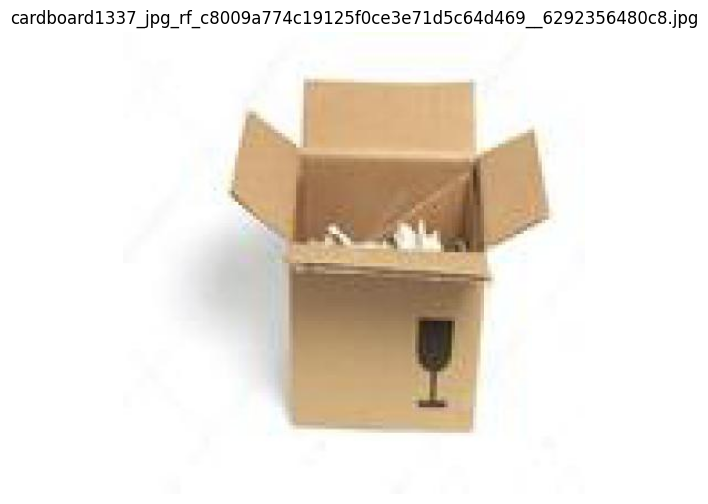

In [25]:
from src.inference import load_artifacts, predict_image

if IMAGE_PATH in (None, ""):
    sample_df = pd.read_csv(PROJECT_ROOT / "data/splits/test.csv")
    image_path = PROJECT_ROOT / "data/interim/images" / sample_df.iloc[0]["relative_path"]
    print("IMAGE_PATH not set. Using sample test image:", image_path)
else:
    image_path = Path(IMAGE_PATH)
    if not image_path.is_absolute():
        image_path = (PROJECT_ROOT / image_path).resolve()

if not MODEL_PATH.exists() or not METADATA_PATH.exists():
    raise FileNotFoundError("Trained model artifacts were not found. Run training first.")

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

model, metadata, device = load_artifacts(MODEL_PATH, METADATA_PATH)
print("Loaded model on device:", device)
print("Classes:", metadata["class_names"])

image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(image_path.name)
plt.axis("off")
plt.show()

Predicted label: paper
Confidence: 0.7889


,label,probability,probability_percent
0,paper,0.788873,78.887284
1,cardboard,0.119716,11.971625
2,glass,0.061814,6.181407
3,metal,0.024928,2.492783
4,biodegradable,0.002725,0.272537


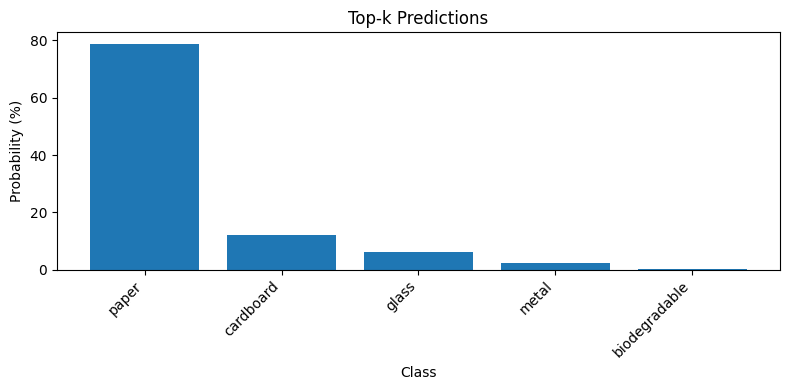

In [26]:
prediction = predict_image(
    image_path=image_path,
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH,
    top_k=TOP_K,
)

print(f"Predicted label: {prediction['predicted_label']}")
print(f"Confidence: {prediction['confidence']:.4f}")

top_k_df = pd.DataFrame(prediction["top_k"])
top_k_df["probability_percent"] = top_k_df["probability"] * 100.0
display(top_k_df)

plt.figure(figsize=(8, 4))
plt.bar(top_k_df["label"], top_k_df["probability_percent"])
plt.ylabel("Probability (%)")
plt.xlabel("Class")
plt.title("Top-k Predictions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()